# Prior Analysis: Control Blocked Test

Analysis of the control_blocked_test.eval log file to test if the agent has a prior against picking cells with the blocked label.

In [2]:
import os
import gc
from inspect_ai.log import EvalLog, read_eval_log
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load the control blocked test log file
log_file = "../logs/control_blocked_test.eval"
log = read_eval_log(log_file, resolve_attachments=False)
print(f"Loaded log file: {log_file}")
print(f"Total samples: {len(log.samples) if log.samples else 0}")

Loaded log file: ../logs/control_blocked_test.eval
Total samples: 2000


## Overall Accuracy Analysis

In [4]:
# Calculate overall accuracy and accuracy by sample type
assert log.samples is not None

total_samples = 0
total_correct = 0
control_samples = 0
control_correct = 0
test_samples = 0
test_correct = 0

for sample in log.samples:
    total_samples += 1
    is_correct = sample.score.value == "C" if sample.scores else False
    if is_correct:
        total_correct += 1
    
    sample_type = sample.metadata.get("sample_type", "unknown")
    if sample_type == "control":
        control_samples += 1
        if is_correct:
            control_correct += 1
    elif sample_type == "test":
        test_samples += 1
        if is_correct:
            test_correct += 1

print(f"Overall Accuracy: {total_correct}/{total_samples} = {total_correct/total_samples:.3f}")
print(f"Control Accuracy: {control_correct}/{control_samples} = {control_correct/control_samples:.3f}")
print(f"Test Accuracy: {test_correct}/{test_samples} = {test_correct/test_samples:.3f}")

The 'score' field is deprecated. Access sample scores through 'scores' instead.


Overall Accuracy: 1654/2000 = 0.827
Control Accuracy: 935/1000 = 0.935
Test Accuracy: 719/1000 = 0.719


## Accuracy by Selection Rule and Sample Type

In [5]:
# Calculate accuracy by selection_rule split by sample_type
rule_sample_accuracy = defaultdict(lambda: {
    'control': {'correct': 0, 'total': 0},
    'test': {'correct': 0, 'total': 0}
})

for sample in log.samples:
    if ("selection_rule_type" in sample.metadata and 
        "sample_type" in sample.metadata):
        
        rule = sample.metadata["selection_rule_type"]
        sample_type = sample.metadata["sample_type"]
        
        # Count total and correct
        rule_sample_accuracy[rule][sample_type]['total'] += 1
        if sample.score.value == "C":
            rule_sample_accuracy[rule][sample_type]['correct'] += 1

# Print summary
print("Accuracy by Selection Rule and Sample Type:")
for rule in sorted(rule_sample_accuracy.keys()):
    print(f"\n{rule}:")
    for sample_type in ['control', 'test']:
        total = rule_sample_accuracy[rule][sample_type]['total']
        correct = rule_sample_accuracy[rule][sample_type]['correct']
        if total > 0:
            accuracy = correct / total
            print(f"  {sample_type}: {correct}/{total} = {accuracy:.3f}")
        else:
            print(f"  {sample_type}: no samples")

Accuracy by Selection Rule and Sample Type:

none:
  control: 250/250 = 1.000
  test: 249/250 = 0.996

size_related:
  control: 250/250 = 1.000
  test: 248/250 = 0.992

spatial_different_perspective:
  control: 199/250 = 0.796
  test: 82/250 = 0.328

spatial_same_perspective:
  control: 236/250 = 0.944
  test: 140/250 = 0.560


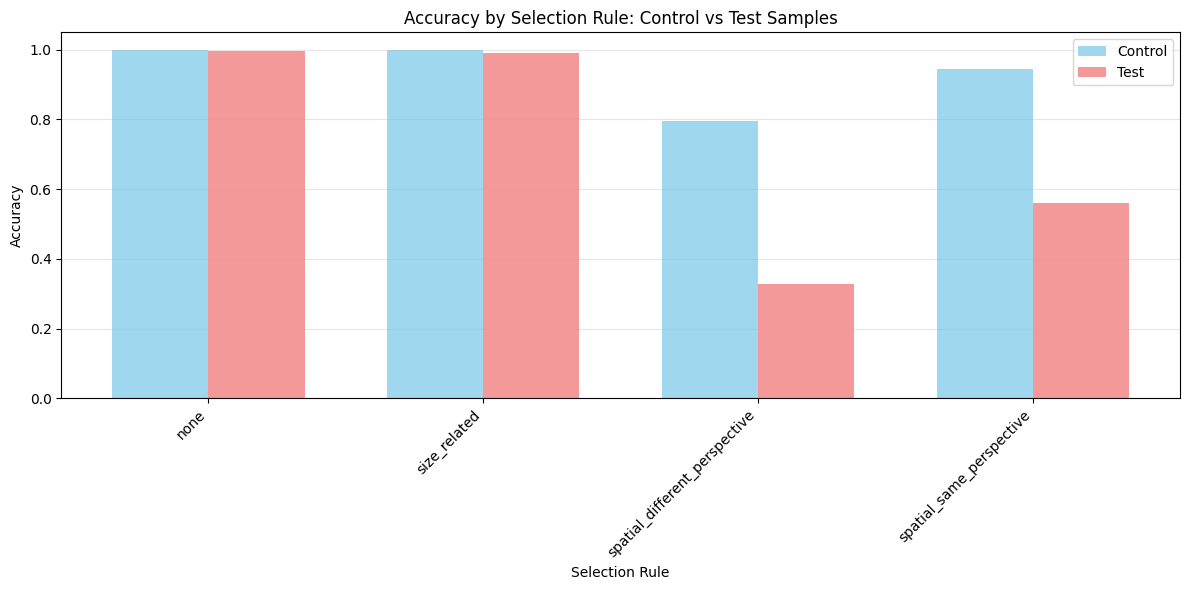

In [6]:
# Visualize accuracy by selection rule and sample type
rules = sorted(rule_sample_accuracy.keys())
control_accuracies = []
test_accuracies = []

for rule in rules:
    # Control accuracy
    total = rule_sample_accuracy[rule]['control']['total']
    correct = rule_sample_accuracy[rule]['control']['correct']
    control_accuracies.append(correct / total if total > 0 else 0)
    
    # Test accuracy
    total = rule_sample_accuracy[rule]['test']['total']
    correct = rule_sample_accuracy[rule]['test']['correct']
    test_accuracies.append(correct / total if total > 0 else 0)

# Create grouped bar chart
plt.figure(figsize=(12, 6))
x = np.arange(len(rules))
width = 0.35

plt.bar(x - width/2, control_accuracies, width, label='Control', alpha=0.8, color='skyblue')
plt.bar(x + width/2, test_accuracies, width, label='Test', alpha=0.8, color='lightcoral')

plt.xlabel('Selection Rule')
plt.ylabel('Accuracy')
plt.title('Accuracy by Selection Rule: Control vs Test Samples')
plt.xticks(x, rules, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Accuracy by Selection Rule and Reversal

In [7]:
# Calculate accuracy by selection_rule split by is_reversed
rule_reversal_accuracy = defaultdict(lambda: {
    'reversed': {'correct': 0, 'total': 0},
    'not_reversed': {'correct': 0, 'total': 0}
})

for sample in log.samples:
    if ("selection_rule_type" in sample.metadata and 
        "is_reversed" in sample.metadata):
        
        rule = sample.metadata["selection_rule_type"]
        is_reversed = sample.metadata["is_reversed"]
        
        # Determine category
        category = 'reversed' if is_reversed else 'not_reversed'
        
        # Count total and correct
        rule_reversal_accuracy[rule][category]['total'] += 1
        if sample.score.value == "C":
            rule_reversal_accuracy[rule][category]['correct'] += 1

# Print summary
print("Accuracy by Selection Rule and Reversal:")
for rule in sorted(rule_reversal_accuracy.keys()):
    print(f"\n{rule}:")
    for category in ['not_reversed', 'reversed']:
        total = rule_reversal_accuracy[rule][category]['total']
        correct = rule_reversal_accuracy[rule][category]['correct']
        if total > 0:
            accuracy = correct / total
            print(f"  {category}: {correct}/{total} = {accuracy:.3f}")
        else:
            print(f"  {category}: no samples")

Accuracy by Selection Rule and Reversal:

none:
  not_reversed: 263/263 = 1.000
  reversed: 236/237 = 0.996

size_related:
  not_reversed: 262/263 = 0.996
  reversed: 236/237 = 0.996

spatial_different_perspective:
  not_reversed: 137/238 = 0.576
  reversed: 144/262 = 0.550

spatial_same_perspective:
  not_reversed: 180/245 = 0.735
  reversed: 196/255 = 0.769


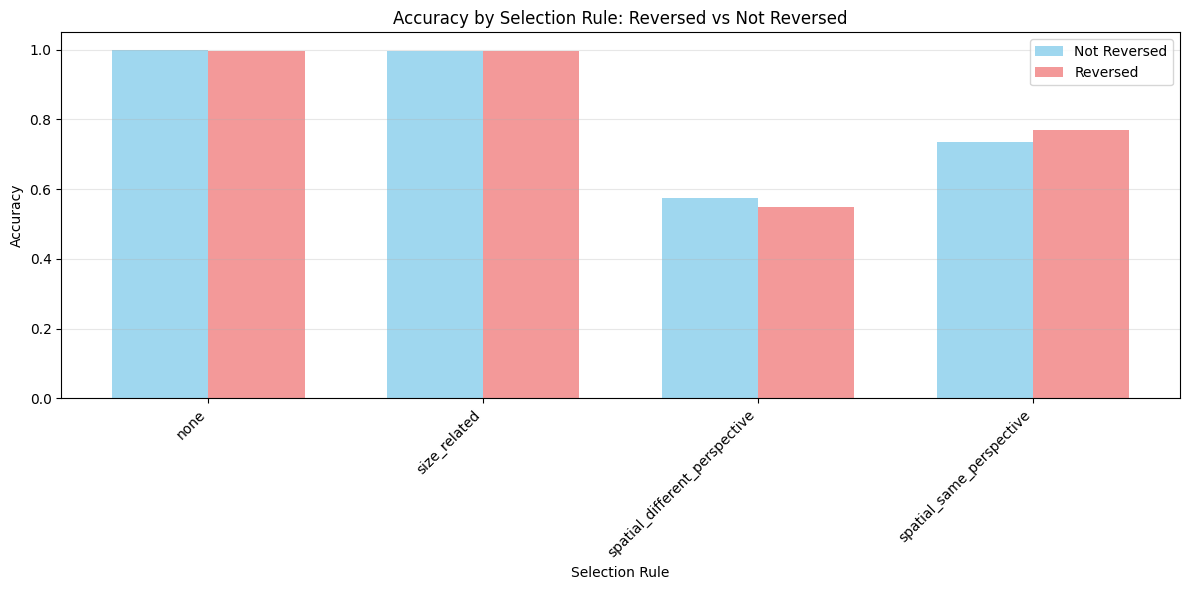

In [8]:
# Visualize selection rule accuracy by reversal - grouped bar chart
plt.figure(figsize=(12, 6))

# Prepare data for plotting
rules = sorted(rule_reversal_accuracy.keys())
not_reversed_accuracies = []
reversed_accuracies = []

for rule in rules:
    # Not reversed accuracy
    total = rule_reversal_accuracy[rule]['not_reversed']['total']
    correct = rule_reversal_accuracy[rule]['not_reversed']['correct']
    not_reversed_accuracies.append(correct / total if total > 0 else 0)
    
    # Reversed accuracy
    total = rule_reversal_accuracy[rule]['reversed']['total']
    correct = rule_reversal_accuracy[rule]['reversed']['correct']
    reversed_accuracies.append(correct / total if total > 0 else 0)

# Create grouped bar chart
x = np.arange(len(rules))
width = 0.35

plt.bar(x - width/2, not_reversed_accuracies, width, label='Not Reversed', alpha=0.8, color='skyblue')
plt.bar(x + width/2, reversed_accuracies, width, label='Reversed', alpha=0.8, color='lightcoral')

plt.xlabel('Selection Rule')
plt.ylabel('Accuracy')
plt.title('Accuracy by Selection Rule: Reversed vs Not Reversed')
plt.xticks(x, rules, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Detailed Analysis: Sample Type × Reversal

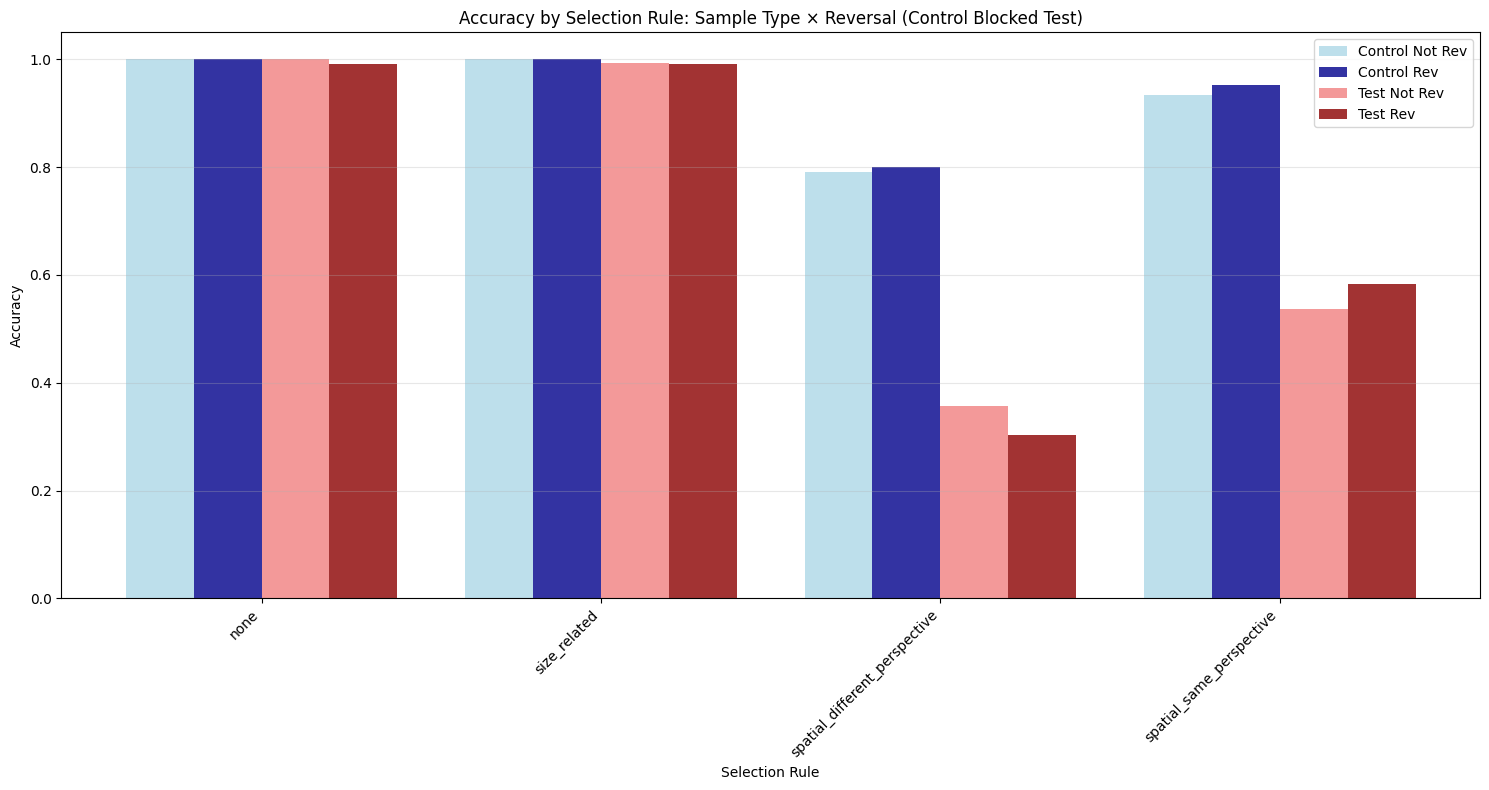


Detailed Summary by Selection Rule:

none:
  Control Not Rev: 127/127 = 1.000
  Control Rev: 123/123 = 1.000
  Test Not Rev: 136/136 = 1.000
  Test Rev: 113/114 = 0.991

size_related:
  Control Not Rev: 125/125 = 1.000
  Control Rev: 125/125 = 1.000
  Test Not Rev: 137/138 = 0.993
  Test Rev: 111/112 = 0.991

spatial_different_perspective:
  Control Not Rev: 95/120 = 0.792
  Control Rev: 104/130 = 0.800
  Test Not Rev: 42/118 = 0.356
  Test Rev: 40/132 = 0.303

spatial_same_perspective:
  Control Not Rev: 114/122 = 0.934
  Control Rev: 122/128 = 0.953
  Test Not Rev: 66/123 = 0.537
  Test Rev: 74/127 = 0.583


In [9]:
# Calculate accuracy by selection_rule split by BOTH sample_type and is_reversed
detailed_accuracy = defaultdict(lambda: {
    'control_not_reversed': {'correct': 0, 'total': 0}, 
    'control_reversed': {'correct': 0, 'total': 0},
    'test_not_reversed': {'correct': 0, 'total': 0}, 
    'test_reversed': {'correct': 0, 'total': 0}
})

# Process samples
for sample in log.samples:
    if ("selection_rule_type" in sample.metadata and 
        "is_reversed" in sample.metadata and 
        "sample_type" in sample.metadata):
        
        rule = sample.metadata["selection_rule_type"]
        is_reversed = sample.metadata["is_reversed"]
        sample_type = sample.metadata["sample_type"]
        
        # Create category key
        category = f"{sample_type}_{'reversed' if is_reversed else 'not_reversed'}"
        
        # Count total and correct
        detailed_accuracy[rule][category]['total'] += 1
        if sample.score.value == "C":
            detailed_accuracy[rule][category]['correct'] += 1

# Calculate accuracies and prepare for plotting
rules = sorted(detailed_accuracy.keys())
categories = ['control_not_reversed', 'control_reversed', 'test_not_reversed', 'test_reversed']
colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']
labels = ['Control Not Rev', 'Control Rev', 'Test Not Rev', 'Test Rev']

# Calculate accuracy percentages
accuracy_data = []
for rule in rules:
    rule_accuracies = []
    for cat in categories:
        total = detailed_accuracy[rule][cat]['total']
        correct = detailed_accuracy[rule][cat]['correct']
        accuracy = correct / total if total > 0 else 0
        rule_accuracies.append(accuracy)
    accuracy_data.append(rule_accuracies)

# Create the grouped bar chart
plt.figure(figsize=(15, 8))

x = np.arange(len(rules))
width = 0.2

for i, (color, label) in enumerate(zip(colors, labels)):
    values = [accuracy_data[j][i] for j in range(len(rules))]
    plt.bar(x + i * width - 1.5*width, values, width, 
           label=label, color=color, alpha=0.8)

plt.xlabel('Selection Rule')
plt.ylabel('Accuracy')
plt.title('Accuracy by Selection Rule: Sample Type × Reversal (Control Blocked Test)')
plt.xticks(x, rules, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDetailed Summary by Selection Rule:")
for rule in rules:
    print(f"\n{rule}:")
    for cat, label in zip(categories, labels):
        total = detailed_accuracy[rule][cat]['total']
        correct = detailed_accuracy[rule][cat]['correct']
        if total > 0:
            accuracy = correct / total
            print(f"  {label}: {correct}/{total} = {accuracy:.3f}")
        else:
            print(f"  {label}: no samples")

## Blocked Cell Analysis

This section specifically analyzes whether the agent shows a prior against selecting cells labeled as 'blocked'.

In [10]:
# Analyze agent responses to see if they avoid "blocked" cells
# This requires examining the agent's actual responses and the grid layouts

blocked_analysis = {
    'total_samples': 0,
    'samples_with_blocked_option': 0,
    'chose_blocked_when_available': 0,
    'avoided_blocked_when_available': 0
}

for sample in log.samples:
    blocked_analysis['total_samples'] += 1
    
    # Check if there are blocked cells in the options
    # This would require examining the sample input/metadata to see grid layout
    # For now, we'll analyze what we can from available metadata
    
    if 'grid' in sample.metadata or 'blocked_cells' in sample.metadata:
        # If we have grid information, we could analyze blocked cell selections
        pass

print(f"Total samples analyzed: {blocked_analysis['total_samples']}")

# Let's examine some sample metadata to see what information is available
print("\nSample metadata keys from first few samples:")
for i, sample in enumerate(log.samples[:3]):
    print(f"Sample {i}: {list(sample.metadata.keys())}")
    if 'blocked_cells' in sample.metadata:
        print(f"  Blocked cells: {sample.metadata['blocked_cells']}")
    if sample.input:
        print(f"  Input length: {len(str(sample.input))}")
    if sample.output:
        print(f"  Output: {sample.output.completion[:100] if len(str(sample.output.completion)) > 100 else sample.output.completion}")
    print()

Total samples analyzed: 2000

Sample metadata keys from first few samples:
Sample 0: ['grid_image', 'grid_width', 'grid_height', 'items', 'sample_type', 'answer_coordinates', 'participant_coordinates', 'director_answer_coordinates', 'selection_rule_type', 'is_physics', 'is_reversed', 'question', 'block_description']
  Input length: 40
  Output: C3

Sample 1: ['grid_image', 'grid_width', 'grid_height', 'items', 'sample_type', 'answer_coordinates', 'participant_coordinates', 'director_answer_coordinates', 'selection_rule_type', 'is_physics', 'is_reversed', 'question', 'block_description']
  Input length: 30
  Output: B1

Sample 2: ['grid_image', 'grid_width', 'grid_height', 'items', 'sample_type', 'answer_coordinates', 'participant_coordinates', 'director_answer_coordinates', 'selection_rule_type', 'is_physics', 'is_reversed', 'question', 'block_description']
  Input length: 36
  Output: A1



In [11]:
# Analyze the actual responses to look for patterns in cell selection
response_patterns = {
    'contains_blocked_mention': 0,
    'contains_coordinate_selection': 0,
    'total_responses': 0
}

coordinate_selections = []
blocked_mentions = []

for sample in log.samples:
    if sample.output and sample.output.completion:
        response = str(sample.output.completion).lower()
        response_patterns['total_responses'] += 1
        
        # Check for mentions of "blocked"
        if 'blocked' in response:
            response_patterns['contains_blocked_mention'] += 1
            blocked_mentions.append(response[:200])  # First 200 chars
        
        # Look for coordinate patterns (e.g., (1,2), [1,2], etc.)
        import re
        coord_pattern = r'[\(\[]?\d+[,\s]+\d+[\)\]]?'
        if re.search(coord_pattern, response):
            response_patterns['contains_coordinate_selection'] += 1
            coords = re.findall(coord_pattern, response)
            coordinate_selections.extend(coords[:3])  # Max 3 per sample

print(f"Response Analysis:")
print(f"Total responses: {response_patterns['total_responses']}")
print(f"Responses mentioning 'blocked': {response_patterns['contains_blocked_mention']} ({response_patterns['contains_blocked_mention']/response_patterns['total_responses']*100:.1f}%)")
print(f"Responses with coordinates: {response_patterns['contains_coordinate_selection']} ({response_patterns['contains_coordinate_selection']/response_patterns['total_responses']*100:.1f}%)")

if blocked_mentions:
    print(f"\nFirst few responses mentioning 'blocked':")
    for i, mention in enumerate(blocked_mentions[:3]):
        print(f"{i+1}: {mention}...")

if coordinate_selections:
    print(f"\nFirst few coordinate selections found:")
    for i, coord in enumerate(coordinate_selections[:10]):
        print(f"{i+1}: {coord}")

Response Analysis:
Total responses: 2000
Responses mentioning 'blocked': 0 (0.0%)
Responses with coordinates: 0 (0.0%)


## Filter to Multiple Choice Samples with Mixed Blocked/Unblocked Options

Filter to only samples that have multiple answer options where at least one option is unblocked. This isolates cases where the agent had a meaningful choice between blocked and unblocked cells.

In [12]:
# Filter samples to those with multiple answers where at least one is unblocked
import json

def parse_coordinate_string(coord_str):
    """Parse coordinate string like 'A1', 'B2' etc or list like [1, 1] into (col, row) tuples"""
    #print(f"parsing string: {coord_str}")
    
    # Handle list/tuple format like [1, 1] or (1, 1)
    if isinstance(coord_str, (list, tuple)) and len(coord_str) >= 2:
        return (int(coord_str[0]), int(coord_str[1]))
    
    # Handle string format like "A1", "B2"
    if isinstance(coord_str, str) and len(coord_str) >= 2:
        col = ord(coord_str[0].upper()) - ord('A')  # A=0, B=1, C=2, etc.
        try:
            row = int(coord_str[1:]) - 1  # Convert to 0-based indexing
            return (col, row)
        except ValueError:
            return None
    
    # Handle single integer or other formats
    print(f"  Warning: Unrecognized coordinate format: {coord_str}")
    return None

def check_if_blocked(coordinate, items):
    """Check if a coordinate corresponds to a blocked cell"""
    coord_tuple = parse_coordinate_string(coordinate)
    if coord_tuple is None:
        return False
    
    col, row = coord_tuple
    
    # Find the item at this coordinate
    for item in items:
        item_col = item["position"].get('x', -1)
        item_row = item["position"].get('y', -1) 
        if item_col == col and item_row == row:
            # Look for block-related properties in the item
            return item["is_blocked"]
    print(f"could not find item position: {coord_tuple}")
    return False

# Analyze answer options
filtered_samples = []
analysis_stats = {
    'total_samples': 0,
    'multiple_choice_samples': 0,
    'samples_with_blocked_options': 0,
    'samples_with_mixed_options': 0,  # Has both blocked and unblocked options
    'filtered_samples': 0
}

print("Analyzing answer options...")

for sample in log.samples:
    analysis_stats['total_samples'] += 1
    
    # Get answer coordinates
    answer_coords = sample.metadata.get('participant_coordinates', [])
    items = sample.metadata.get('items', [])
    
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    if not isinstance(answer_coords, list) or len(answer_coords) < 2:
        continue
    
    analysis_stats['multiple_choice_samples'] += 1
    
    # Check which answers are blocked
    blocked_status = []
    for coord in answer_coords:
        is_blocked = check_if_blocked(coord, items)
        blocked_status.append(is_blocked)
    
    has_blocked = any(blocked_status)
    has_unblocked = any(not status for status in blocked_status)
    
    if has_blocked:
        analysis_stats['samples_with_blocked_options'] += 1
    
    if has_blocked and has_unblocked:
        analysis_stats['samples_with_mixed_options'] += 1
        filtered_samples.append(sample)
        analysis_stats['filtered_samples'] += 1

print("\\nFiltering Results:")
print(f"Total samples: {analysis_stats['total_samples']}")
print(f"Multiple choice samples: {analysis_stats['multiple_choice_samples']}")
print(f"Samples with blocked options: {analysis_stats['samples_with_blocked_options']}")
print(f"Samples with mixed (blocked + unblocked) options: {analysis_stats['samples_with_mixed_options']}")
print(f"Final filtered sample count: {analysis_stats['filtered_samples']}")

print("\\nFirst few examples of filtered samples:")
for i, sample in enumerate(filtered_samples[:3]):
    answer_coords = sample.metadata.get('answer_coordinates', [])
    items = sample.metadata.get('items', [])
    
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    print(f"\\nSample {i+1}:")
    print(f"  Answer options: {answer_coords}")
    print(f"  Agent response: {sample.output.completion if sample.output else 'N/A'}")
    
    # Show blocked status of each option
    for coord in answer_coords:
        is_blocked = check_if_blocked(coord, items)
        print(f"    {coord}: {'BLOCKED' if is_blocked else 'unblocked'}")

print(f"\\n=== FILTERING COMPLETE ===")
print(f"Created filtered_samples with {len(filtered_samples)} samples")

Analyzing answer options...
\nFiltering Results:
Total samples: 2000
Multiple choice samples: 856
Samples with blocked options: 856
Samples with mixed (blocked + unblocked) options: 644
Final filtered sample count: 644
\nFirst few examples of filtered samples:
\nSample 1:
  Answer options: [[1, 1], [0, 3]]
  Agent response: B2
    [1, 1]: BLOCKED
    [0, 3]: unblocked
\nSample 2:
  Answer options: [[0, 1], [0, 0]]
  Agent response: A2
    [0, 1]: unblocked
    [0, 0]: BLOCKED
\nSample 3:
  Answer options: [[0, 1], [2, 1], [1, 1], [0, 3], [2, 0], [3, 0], [2, 3], [0, 2], [2, 2]]
  Agent response: C1
    [0, 1]: BLOCKED
    [2, 1]: BLOCKED
    [1, 1]: BLOCKED
    [0, 3]: BLOCKED
    [2, 0]: unblocked
    [3, 0]: BLOCKED
    [2, 3]: BLOCKED
    [0, 2]: BLOCKED
    [2, 2]: BLOCKED
\n=== FILTERING COMPLETE ===
Created filtered_samples with 644 samples


Analyzing 644 filtered samples...

=== FILTERED SAMPLES ANALYSIS ===
Total filtered samples: 644
Unparseable responses: 0 (0.0%)
Agent picked invalid answer: 25 (3.9%)
Agent picked BLOCKED answer: 99 (15.4%)
Agent picked UNBLOCKED answer: 520 (80.7%)

=== OF VALID RESPONSES ONLY ===
Total valid responses: 619
Chose BLOCKED: 99 (16.0%)
Chose UNBLOCKED: 520 (84.0%)


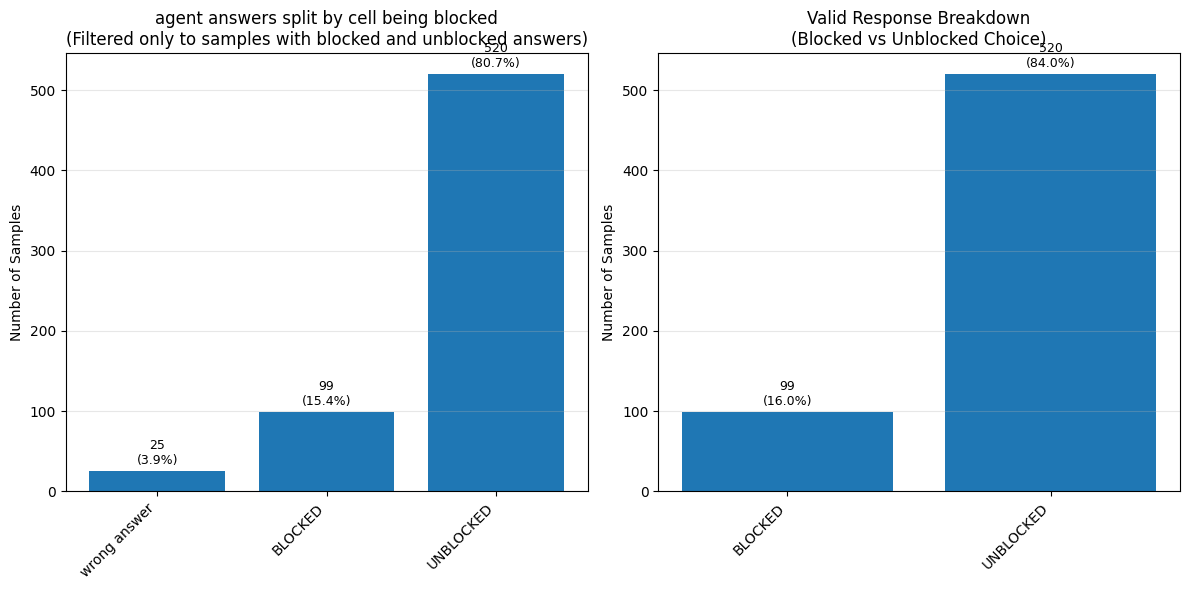

In [13]:
# Analysis of filtered samples: agent choice patterns for blocked vs unblocked cells
import json

def parse_agent_response(response_str):
    """Parse agent response to extract coordinate"""
    if not response_str:
        return None
    
    response = str(response_str).strip()
    
    # Try to parse as coordinate like "A1", "B2", "C3"
    if len(response) >= 2:
        try:
            col = ord(response[0].upper()) - ord('A')
            row = int(response[1:]) - 1
            return [col, row]
        except (ValueError, IndexError):
            pass
    
    return None

def coords_match(coord1, coord2):
    """Check if two coordinates match (handling different formats)"""
    if coord1 is None or coord2 is None:
        return False
    
    # Convert both to [col, row] format
    c1 = coord1 if isinstance(coord1, list) else [coord1[0], coord1[1]]
    c2 = coord2 if isinstance(coord2, list) else [coord2[0], coord2[1]]
    
    return c1[0] == c2[0] and c1[1] == c2[1]

# Analyze filtered samples
filtered_analysis = {
    'total_filtered': len(filtered_samples),
    'agent_wrong': 0,  # Response not in answer list
    'agent_picked_unblocked': 0,
    'agent_picked_blocked': 0,
    'unparseable_responses': 0
}

print(f"Analyzing {len(filtered_samples)} filtered samples...")

for sample in filtered_samples:
    # Get agent response
    agent_response = sample.output.completion if sample.output else None
    agent_coord = parse_agent_response(agent_response)
    
    # Get answer coordinates
    answer_coords = sample.metadata.get('answer_coordinates', [])
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    # Get items for blocked checking
    items = sample.metadata.get('items', [])
    
    if agent_coord is None:
        filtered_analysis['unparseable_responses'] += 1
        continue
    
    # Check if agent response is in the answer list
    agent_in_answers = any(coords_match(agent_coord, ans_coord) for ans_coord in answer_coords)
    
    if not agent_in_answers:
        filtered_analysis['agent_wrong'] += 1
    else:
        # Agent picked a valid answer - check if it's blocked or unblocked
        agent_blocked = check_if_blocked(agent_coord, items)
        
        if agent_blocked:
            filtered_analysis['agent_picked_blocked'] += 1
        else:
            filtered_analysis['agent_picked_unblocked'] += 1

# Calculate percentages
total = filtered_analysis['total_filtered']
print(f"\n=== FILTERED SAMPLES ANALYSIS ===")
print(f"Total filtered samples: {total}")
print(f"Unparseable responses: {filtered_analysis['unparseable_responses']} ({filtered_analysis['unparseable_responses']/total*100:.1f}%)")
print(f"Agent picked invalid answer: {filtered_analysis['agent_wrong']} ({filtered_analysis['agent_wrong']/total*100:.1f}%)")
print(f"Agent picked BLOCKED answer: {filtered_analysis['agent_picked_blocked']} ({filtered_analysis['agent_picked_blocked']/total*100:.1f}%)")
print(f"Agent picked UNBLOCKED answer: {filtered_analysis['agent_picked_unblocked']} ({filtered_analysis['agent_picked_unblocked']/total*100:.1f}%)")

# Additional analysis: of valid responses, what % were blocked vs unblocked?
valid_responses = filtered_analysis['agent_picked_blocked'] + filtered_analysis['agent_picked_unblocked']
if valid_responses > 0:
    print(f"\n=== OF VALID RESPONSES ONLY ===")
    print(f"Total valid responses: {valid_responses}")
    print(f"Chose BLOCKED: {filtered_analysis['agent_picked_blocked']} ({filtered_analysis['agent_picked_blocked']/valid_responses*100:.1f}%)")
    print(f"Chose UNBLOCKED: {filtered_analysis['agent_picked_unblocked']} ({filtered_analysis['agent_picked_unblocked']/valid_responses*100:.1f}%)")

# Create bar chart visualization
plt.figure(figsize=(12, 6))

# First subplot: Overall breakdown (excluding unparseable responses)
plt.subplot(1, 2, 1)
categories = ['wrong answer', 'BLOCKED', 'UNBLOCKED']
counts = [
    filtered_analysis['agent_wrong'],
    filtered_analysis['agent_picked_blocked'], 
    filtered_analysis['agent_picked_unblocked']
]

bars1 = plt.bar(categories, counts)
plt.title('agent answers split by cell being blocked\n(Filtered only to samples with blocked and unblocked answers)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars1, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/total*100:.1f}%)', 
             ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')

# Second subplot: Valid responses only
if valid_responses > 0:
    plt.subplot(1, 2, 2)
    valid_categories = ['BLOCKED', 'UNBLOCKED']
    valid_counts = [
        filtered_analysis['agent_picked_blocked'],
        filtered_analysis['agent_picked_unblocked']
    ]
    
    bars2 = plt.bar(valid_categories, valid_counts)
    plt.title('Valid Response Breakdown\n(Blocked vs Unblocked Choice)')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, count in zip(bars2, valid_counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count}\n({count/valid_responses*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=9)
    
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Filtering to samples where ALL correct answers are blocked...

=== ALL-BLOCKED SAMPLES FILTERING RESULTS ===
Total samples checked: 2000
Multiple choice samples: 2000
Samples where ALL correct answers are blocked: 356

=== ACCURACY COMPARISON ===
Mixed samples (blocked + unblocked answers): 619/644 = 0.961
All-blocked samples (all answers blocked): 100/356 = 0.281


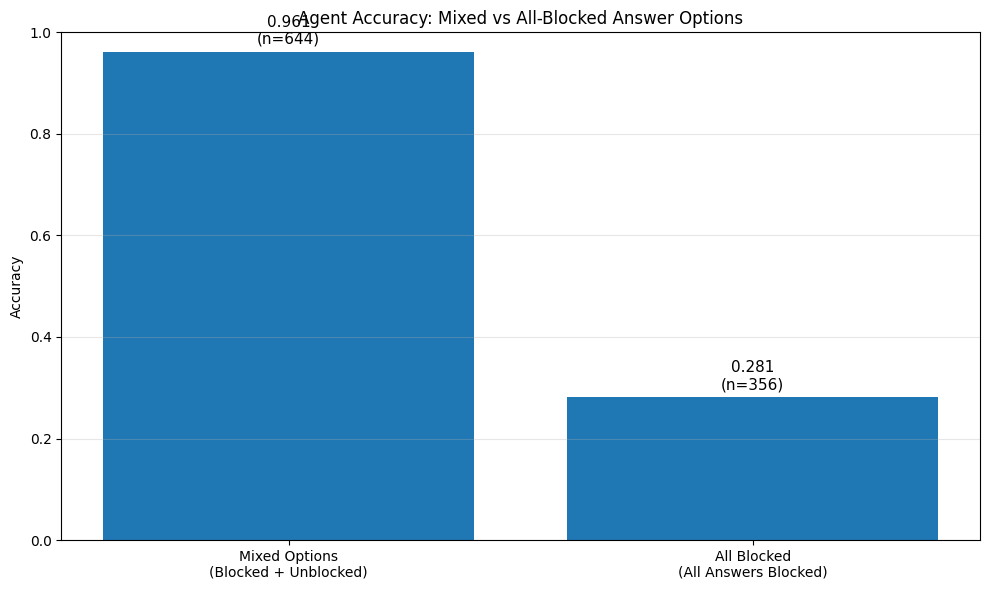


=== SUMMARY ===
Mixed samples (blocked + unblocked answers): 644 samples, 0.961 accuracy
All-blocked samples (all answers blocked): 356 samples, 0.281 accuracy
Accuracy difference: 0.680 (higher for mixed samples)


In [14]:
# Filter to samples where ALL correct answers are blocked
all_blocked_samples = []
all_blocked_stats = {
    'total_samples_checked': 0,
    'multiple_choice_samples': 0,
    'samples_with_all_blocked_answers': 0
}

print("Filtering to samples where ALL correct answers are blocked...")

for sample in log.samples:
    all_blocked_stats['total_samples_checked'] += 1
    
    # Get answer coordinates (the correct answers)
    answer_coords = sample.metadata.get('answer_coordinates', [])
    items = sample.metadata.get('items', [])
    
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    if not isinstance(answer_coords, list) or len(answer_coords) < 1:
        continue
    
    all_blocked_stats['multiple_choice_samples'] += 1
    
    # Check if ALL correct answers are blocked
    all_answers_blocked = True
    for coord in answer_coords:
        is_blocked = check_if_blocked(coord, items)
        if not is_blocked:
            all_answers_blocked = False
            break
    
    if all_answers_blocked:
        all_blocked_stats['samples_with_all_blocked_answers'] += 1
        all_blocked_samples.append(sample)

print(f"\n=== ALL-BLOCKED SAMPLES FILTERING RESULTS ===")
print(f"Total samples checked: {all_blocked_stats['total_samples_checked']}")
print(f"Multiple choice samples: {all_blocked_stats['multiple_choice_samples']}")
print(f"Samples where ALL correct answers are blocked: {all_blocked_stats['samples_with_all_blocked_answers']}")

# Calculate accuracy for different sample groups
def calculate_accuracy(sample_list, group_name):
    """Calculate accuracy for a list of samples"""
    if not sample_list:
        return 0, 0, 0
    
    correct_count = 0
    total_count = len(sample_list)
    
    for sample in sample_list:
        if sample.scores and len(sample.scores) > 0:
            is_correct = sample.score.value == "C"
            if is_correct:
                correct_count += 1
    
    accuracy = correct_count / total_count if total_count > 0 else 0
    print(f"{group_name}: {correct_count}/{total_count} = {accuracy:.3f}")
    return correct_count, total_count, accuracy

# Calculate accuracies for comparison
print(f"\n=== ACCURACY COMPARISON ===")
_, _, mixed_accuracy = calculate_accuracy(filtered_samples, "Mixed samples (blocked + unblocked answers)")
_, _, all_blocked_accuracy = calculate_accuracy(all_blocked_samples, "All-blocked samples (all answers blocked)")

# Create comparison bar chart
plt.figure(figsize=(10, 6))

groups = ['Mixed Options\n(Blocked + Unblocked)', 'All Blocked\n(All Answers Blocked)']
accuracies = [mixed_accuracy, all_blocked_accuracy]
sample_counts = [len(filtered_samples), len(all_blocked_samples)]

# Create bars
bars = plt.bar(groups, accuracies)

# Add value labels on bars
for bar, accuracy, count in zip(bars, accuracies, sample_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.3f}\n(n={count})', 
             ha='center', va='bottom', fontsize=11)

plt.ylabel('Accuracy')
plt.title('Agent Accuracy: Mixed vs All-Blocked Answer Options')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Mixed samples (blocked + unblocked answers): {len(filtered_samples)} samples, {mixed_accuracy:.3f} accuracy")
print(f"All-blocked samples (all answers blocked): {len(all_blocked_samples)} samples, {all_blocked_accuracy:.3f} accuracy")
if len(all_blocked_samples) > 0 and len(filtered_samples) > 0:
    accuracy_diff = mixed_accuracy - all_blocked_accuracy
    print(f"Accuracy difference: {accuracy_diff:.3f} ({'higher' if accuracy_diff > 0 else 'lower'} for mixed samples)")

# material backing

In [15]:
# Load the control blocked test log file
log_file = "../logs/control_material_test.eval"
log = read_eval_log(log_file, resolve_attachments=False)
print(f"Loaded log file: {log_file}")
print(f"Total samples: {len(log.samples) if log.samples else 0}")

Loaded log file: ../logs/control_material_test.eval
Total samples: 2000


In [16]:
# Calculate overall accuracy and accuracy by sample type
assert log.samples is not None

total_samples = 0
total_correct = 0
control_samples = 0
control_correct = 0
test_samples = 0
test_correct = 0

for sample in log.samples:
    total_samples += 1
    is_correct = sample.score.value == "C" if sample.scores else False
    if is_correct:
        total_correct += 1
    
    sample_type = sample.metadata.get("sample_type", "unknown")
    if sample_type == "control":
        control_samples += 1
        if is_correct:
            control_correct += 1
    elif sample_type == "test":
        test_samples += 1
        if is_correct:
            test_correct += 1

print(f"Overall Accuracy: {total_correct}/{total_samples} = {total_correct/total_samples:.3f}")
print(f"Control Accuracy: {control_correct}/{control_samples} = {control_correct/control_samples:.3f}")
print(f"Test Accuracy: {test_correct}/{test_samples} = {test_correct/test_samples:.3f}")

Overall Accuracy: 1832/2000 = 0.916
Control Accuracy: 875/1000 = 0.875
Test Accuracy: 957/1000 = 0.957


In [17]:
# Calculate accuracy by selection_rule split by sample_type
rule_sample_accuracy = defaultdict(lambda: {
    'control': {'correct': 0, 'total': 0},
    'test': {'correct': 0, 'total': 0}
})

for sample in log.samples:
    if ("selection_rule_type" in sample.metadata and 
        "sample_type" in sample.metadata):
        
        rule = sample.metadata["selection_rule_type"]
        sample_type = sample.metadata["sample_type"]
        
        # Count total and correct
        rule_sample_accuracy[rule][sample_type]['total'] += 1
        if sample.score.value == "C":
            rule_sample_accuracy[rule][sample_type]['correct'] += 1

# Print summary
print("Accuracy by Selection Rule and Sample Type:")
for rule in sorted(rule_sample_accuracy.keys()):
    print(f"\n{rule}:")
    for sample_type in ['control', 'test']:
        total = rule_sample_accuracy[rule][sample_type]['total']
        correct = rule_sample_accuracy[rule][sample_type]['correct']
        if total > 0:
            accuracy = correct / total
            print(f"  {sample_type}: {correct}/{total} = {accuracy:.3f}")
        else:
            print(f"  {sample_type}: no samples")

Accuracy by Selection Rule and Sample Type:

none:
  control: 250/250 = 1.000
  test: 250/250 = 1.000

size_related:
  control: 250/250 = 1.000
  test: 250/250 = 1.000

spatial_different_perspective:
  control: 149/250 = 0.596
  test: 214/250 = 0.856

spatial_same_perspective:
  control: 226/250 = 0.904
  test: 243/250 = 0.972


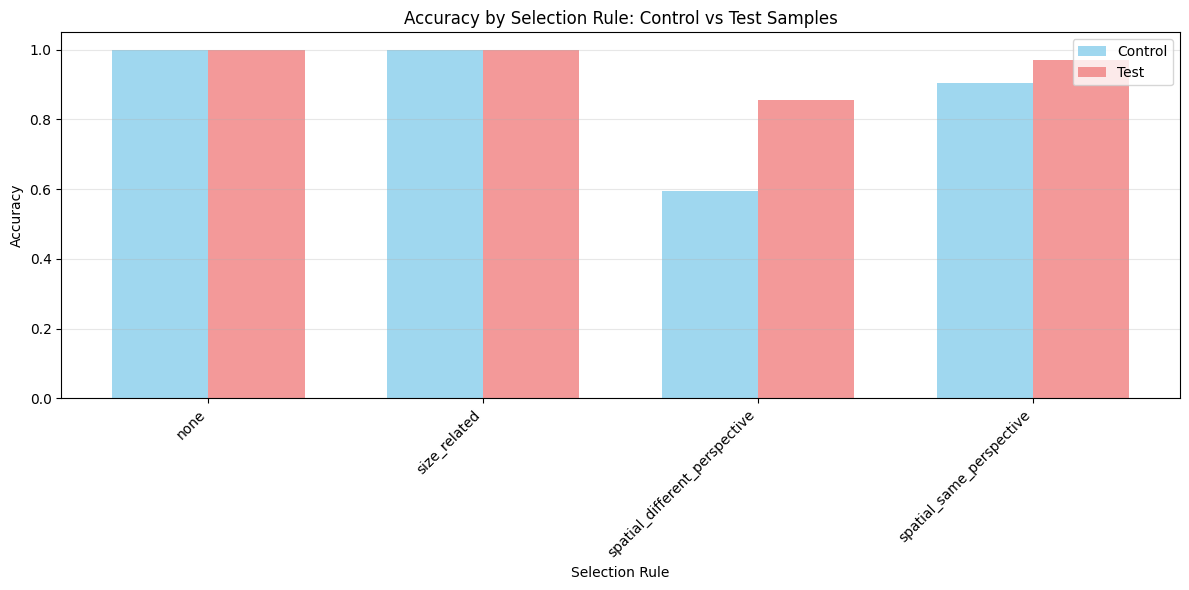

In [18]:
# Visualize accuracy by selection rule and sample type
rules = sorted(rule_sample_accuracy.keys())
control_accuracies = []
test_accuracies = []

for rule in rules:
    # Control accuracy
    total = rule_sample_accuracy[rule]['control']['total']
    correct = rule_sample_accuracy[rule]['control']['correct']
    control_accuracies.append(correct / total if total > 0 else 0)
    
    # Test accuracy
    total = rule_sample_accuracy[rule]['test']['total']
    correct = rule_sample_accuracy[rule]['test']['correct']
    test_accuracies.append(correct / total if total > 0 else 0)

# Create grouped bar chart
plt.figure(figsize=(12, 6))
x = np.arange(len(rules))
width = 0.35

plt.bar(x - width/2, control_accuracies, width, label='Control', alpha=0.8, color='skyblue')
plt.bar(x + width/2, test_accuracies, width, label='Test', alpha=0.8, color='lightcoral')

plt.xlabel('Selection Rule')
plt.ylabel('Accuracy')
plt.title('Accuracy by Selection Rule: Control vs Test Samples')
plt.xticks(x, rules, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [19]:
# Calculate accuracy by selection_rule split by is_reversed
rule_reversal_accuracy = defaultdict(lambda: {
    'reversed': {'correct': 0, 'total': 0},
    'not_reversed': {'correct': 0, 'total': 0}
})

for sample in log.samples:
    if ("selection_rule_type" in sample.metadata and 
        "is_reversed" in sample.metadata):
        
        rule = sample.metadata["selection_rule_type"]
        is_reversed = sample.metadata["is_reversed"]
        
        # Determine category
        category = 'reversed' if is_reversed else 'not_reversed'
        
        # Count total and correct
        rule_reversal_accuracy[rule][category]['total'] += 1
        if sample.score.value == "C":
            rule_reversal_accuracy[rule][category]['correct'] += 1

# Print summary
print("Accuracy by Selection Rule and Reversal:")
for rule in sorted(rule_reversal_accuracy.keys()):
    print(f"\n{rule}:")
    for category in ['not_reversed', 'reversed']:
        total = rule_reversal_accuracy[rule][category]['total']
        correct = rule_reversal_accuracy[rule][category]['correct']
        if total > 0:
            accuracy = correct / total
            print(f"  {category}: {correct}/{total} = {accuracy:.3f}")
        else:
            print(f"  {category}: no samples")

Accuracy by Selection Rule and Reversal:

none:
  not_reversed: 263/263 = 1.000
  reversed: 237/237 = 1.000

size_related:
  not_reversed: 263/263 = 1.000
  reversed: 237/237 = 1.000

spatial_different_perspective:
  not_reversed: 176/238 = 0.739
  reversed: 187/262 = 0.714

spatial_same_perspective:
  not_reversed: 226/245 = 0.922
  reversed: 243/255 = 0.953


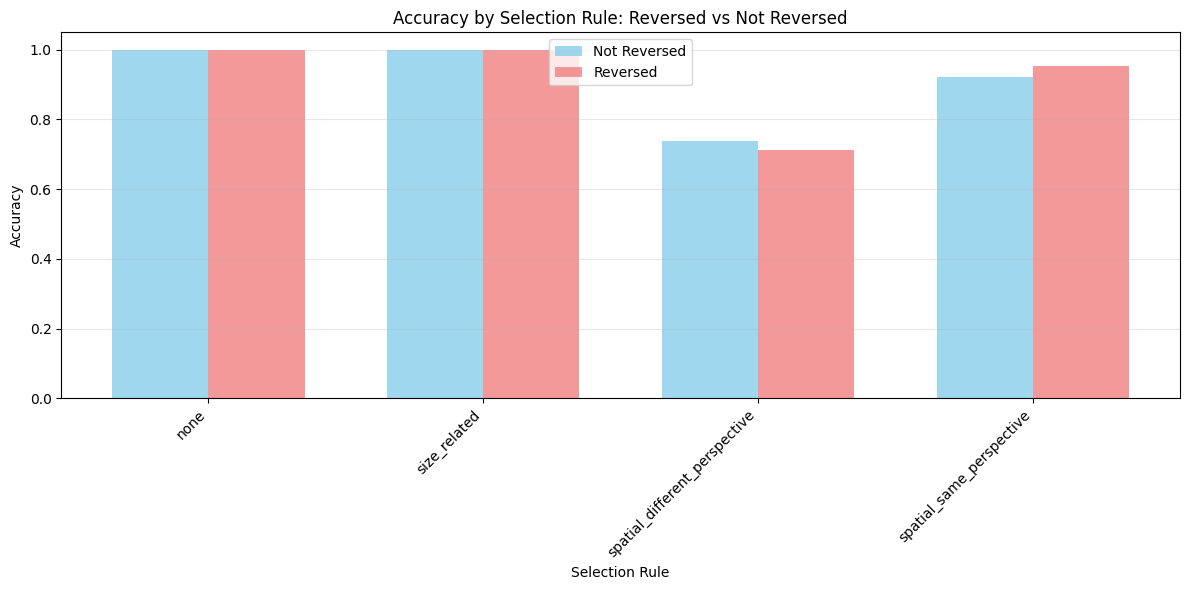

In [20]:
# Visualize selection rule accuracy by reversal - grouped bar chart
plt.figure(figsize=(12, 6))

# Prepare data for plotting
rules = sorted(rule_reversal_accuracy.keys())
not_reversed_accuracies = []
reversed_accuracies = []

for rule in rules:
    # Not reversed accuracy
    total = rule_reversal_accuracy[rule]['not_reversed']['total']
    correct = rule_reversal_accuracy[rule]['not_reversed']['correct']
    not_reversed_accuracies.append(correct / total if total > 0 else 0)
    
    # Reversed accuracy
    total = rule_reversal_accuracy[rule]['reversed']['total']
    correct = rule_reversal_accuracy[rule]['reversed']['correct']
    reversed_accuracies.append(correct / total if total > 0 else 0)

# Create grouped bar chart
x = np.arange(len(rules))
width = 0.35

plt.bar(x - width/2, not_reversed_accuracies, width, label='Not Reversed', alpha=0.8, color='skyblue')
plt.bar(x + width/2, reversed_accuracies, width, label='Reversed', alpha=0.8, color='lightcoral')

plt.xlabel('Selection Rule')
plt.ylabel('Accuracy')
plt.title('Accuracy by Selection Rule: Reversed vs Not Reversed')
plt.xticks(x, rules, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

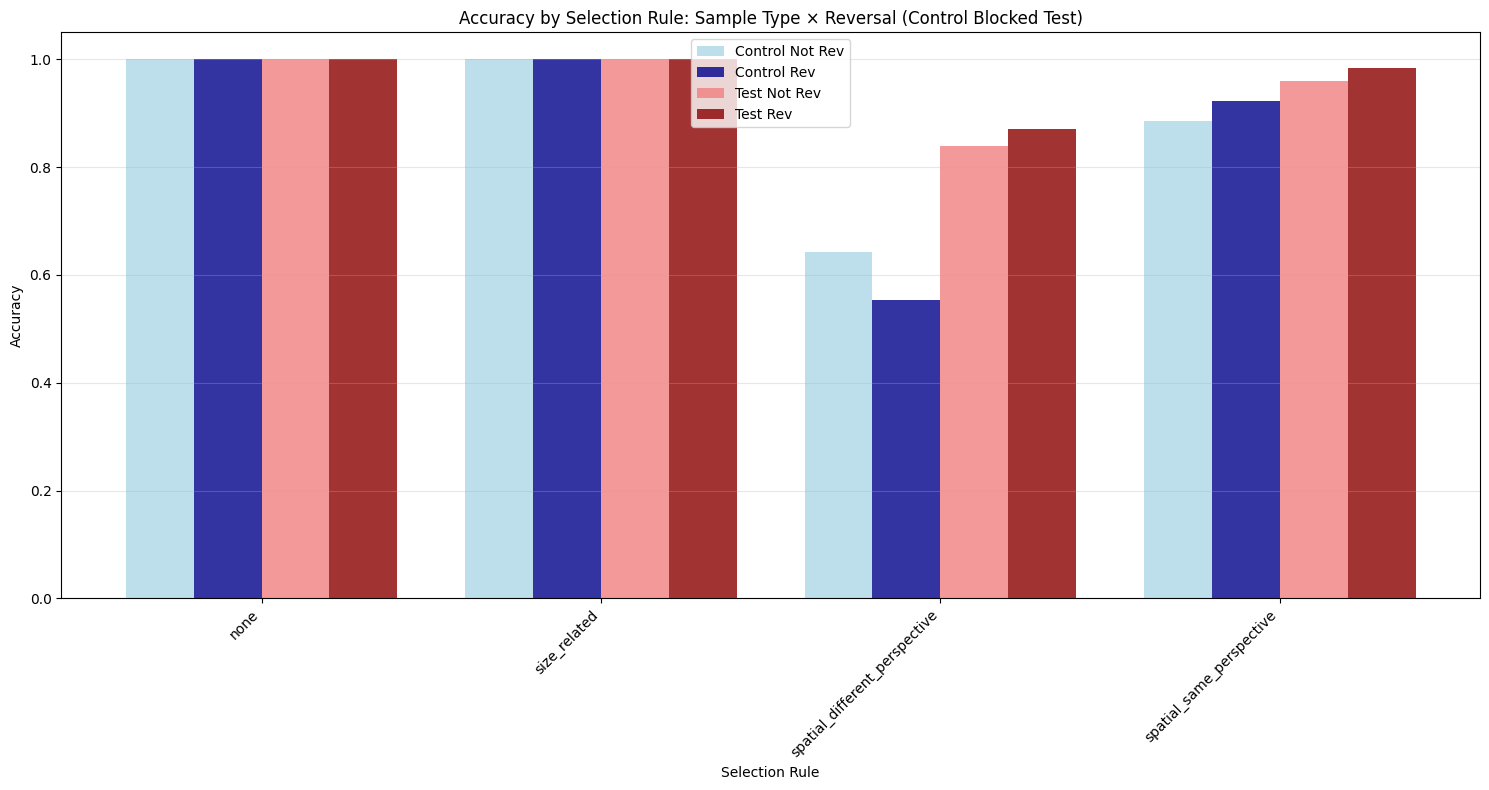


Detailed Summary by Selection Rule:

none:
  Control Not Rev: 127/127 = 1.000
  Control Rev: 123/123 = 1.000
  Test Not Rev: 136/136 = 1.000
  Test Rev: 114/114 = 1.000

size_related:
  Control Not Rev: 125/125 = 1.000
  Control Rev: 125/125 = 1.000
  Test Not Rev: 138/138 = 1.000
  Test Rev: 112/112 = 1.000

spatial_different_perspective:
  Control Not Rev: 77/120 = 0.642
  Control Rev: 72/130 = 0.554
  Test Not Rev: 99/118 = 0.839
  Test Rev: 115/132 = 0.871

spatial_same_perspective:
  Control Not Rev: 108/122 = 0.885
  Control Rev: 118/128 = 0.922
  Test Not Rev: 118/123 = 0.959
  Test Rev: 125/127 = 0.984


In [21]:
# Calculate accuracy by selection_rule split by BOTH sample_type and is_reversed
detailed_accuracy = defaultdict(lambda: {
    'control_not_reversed': {'correct': 0, 'total': 0}, 
    'control_reversed': {'correct': 0, 'total': 0},
    'test_not_reversed': {'correct': 0, 'total': 0}, 
    'test_reversed': {'correct': 0, 'total': 0}
})

# Process samples
for sample in log.samples:
    if ("selection_rule_type" in sample.metadata and 
        "is_reversed" in sample.metadata and 
        "sample_type" in sample.metadata):
        
        rule = sample.metadata["selection_rule_type"]
        is_reversed = sample.metadata["is_reversed"]
        sample_type = sample.metadata["sample_type"]
        
        # Create category key
        category = f"{sample_type}_{'reversed' if is_reversed else 'not_reversed'}"
        
        # Count total and correct
        detailed_accuracy[rule][category]['total'] += 1
        if sample.score.value == "C":
            detailed_accuracy[rule][category]['correct'] += 1

# Calculate accuracies and prepare for plotting
rules = sorted(detailed_accuracy.keys())
categories = ['control_not_reversed', 'control_reversed', 'test_not_reversed', 'test_reversed']
colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']
labels = ['Control Not Rev', 'Control Rev', 'Test Not Rev', 'Test Rev']

# Calculate accuracy percentages
accuracy_data = []
for rule in rules:
    rule_accuracies = []
    for cat in categories:
        total = detailed_accuracy[rule][cat]['total']
        correct = detailed_accuracy[rule][cat]['correct']
        accuracy = correct / total if total > 0 else 0
        rule_accuracies.append(accuracy)
    accuracy_data.append(rule_accuracies)

# Create the grouped bar chart
plt.figure(figsize=(15, 8))

x = np.arange(len(rules))
width = 0.2

for i, (color, label) in enumerate(zip(colors, labels)):
    values = [accuracy_data[j][i] for j in range(len(rules))]
    plt.bar(x + i * width - 1.5*width, values, width, 
           label=label, color=color, alpha=0.8)

plt.xlabel('Selection Rule')
plt.ylabel('Accuracy')
plt.title('Accuracy by Selection Rule: Sample Type × Reversal (Control Blocked Test)')
plt.xticks(x, rules, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDetailed Summary by Selection Rule:")
for rule in rules:
    print(f"\n{rule}:")
    for cat, label in zip(categories, labels):
        total = detailed_accuracy[rule][cat]['total']
        correct = detailed_accuracy[rule][cat]['correct']
        if total > 0:
            accuracy = correct / total
            print(f"  {label}: {correct}/{total} = {accuracy:.3f}")
        else:
            print(f"  {label}: no samples")

In [22]:
# Analyze agent responses to see if they avoid "blocked" cells
# This requires examining the agent's actual responses and the grid layouts

blocked_analysis = {
    'total_samples': 0,
    'samples_with_blocked_option': 0,
    'chose_blocked_when_available': 0,
    'avoided_blocked_when_available': 0
}

for sample in log.samples:
    blocked_analysis['total_samples'] += 1
    
    # Check if there are blocked cells in the options
    # This would require examining the sample input/metadata to see grid layout
    # For now, we'll analyze what we can from available metadata
    
    if 'grid' in sample.metadata or 'blocked_cells' in sample.metadata:
        # If we have grid information, we could analyze blocked cell selections
        pass

print(f"Total samples analyzed: {blocked_analysis['total_samples']}")

# Let's examine some sample metadata to see what information is available
print("\nSample metadata keys from first few samples:")
for i, sample in enumerate(log.samples[:3]):
    print(f"Sample {i}: {list(sample.metadata.keys())}")
    if 'blocked_cells' in sample.metadata:
        print(f"  Blocked cells: {sample.metadata['blocked_cells']}")
    if sample.input:
        print(f"  Input length: {len(str(sample.input))}")
    if sample.output:
        print(f"  Output: {sample.output.completion[:100] if len(str(sample.output.completion)) > 100 else sample.output.completion}")
    print()

Total samples analyzed: 2000

Sample metadata keys from first few samples:
Sample 0: ['grid_image', 'grid_width', 'grid_height', 'items', 'sample_type', 'answer_coordinates', 'participant_coordinates', 'director_answer_coordinates', 'selection_rule_type', 'is_physics', 'is_reversed', 'question', 'block_description']
  Input length: 40
  Output: C3

Sample 1: ['grid_image', 'grid_width', 'grid_height', 'items', 'sample_type', 'answer_coordinates', 'participant_coordinates', 'director_answer_coordinates', 'selection_rule_type', 'is_physics', 'is_reversed', 'question', 'block_description']
  Input length: 30
  Output: B1

Sample 2: ['grid_image', 'grid_width', 'grid_height', 'items', 'sample_type', 'answer_coordinates', 'participant_coordinates', 'director_answer_coordinates', 'selection_rule_type', 'is_physics', 'is_reversed', 'question', 'block_description']
  Input length: 36
  Output: A1



In [23]:
# Analyze the actual responses to look for patterns in cell selection
response_patterns = {
    'contains_blocked_mention': 0,
    'contains_coordinate_selection': 0,
    'total_responses': 0
}

coordinate_selections = []
blocked_mentions = []

for sample in log.samples:
    if sample.output and sample.output.completion:
        response = str(sample.output.completion).lower()
        response_patterns['total_responses'] += 1
        
        # Check for mentions of "blocked"
        if 'blocked' in response:
            response_patterns['contains_blocked_mention'] += 1
            blocked_mentions.append(response[:200])  # First 200 chars
        
        # Look for coordinate patterns (e.g., (1,2), [1,2], etc.)
        import re
        coord_pattern = r'[\(\[]?\d+[,\s]+\d+[\)\]]?'
        if re.search(coord_pattern, response):
            response_patterns['contains_coordinate_selection'] += 1
            coords = re.findall(coord_pattern, response)
            coordinate_selections.extend(coords[:3])  # Max 3 per sample

print(f"Response Analysis:")
print(f"Total responses: {response_patterns['total_responses']}")
print(f"Responses mentioning 'blocked': {response_patterns['contains_blocked_mention']} ({response_patterns['contains_blocked_mention']/response_patterns['total_responses']*100:.1f}%)")
print(f"Responses with coordinates: {response_patterns['contains_coordinate_selection']} ({response_patterns['contains_coordinate_selection']/response_patterns['total_responses']*100:.1f}%)")

if blocked_mentions:
    print(f"\nFirst few responses mentioning 'blocked':")
    for i, mention in enumerate(blocked_mentions[:3]):
        print(f"{i+1}: {mention}...")

if coordinate_selections:
    print(f"\nFirst few coordinate selections found:")
    for i, coord in enumerate(coordinate_selections[:10]):
        print(f"{i+1}: {coord}")

Response Analysis:
Total responses: 2000
Responses mentioning 'blocked': 0 (0.0%)
Responses with coordinates: 0 (0.0%)


In [28]:
# Filter samples to those with multiple answers where at least one is unblocked
import json

from numpy import mean
blocked_unblocked_ratios = []

def parse_coordinate_string(coord_str):
    """Parse coordinate string like 'A1', 'B2' etc or list like [1, 1] into (col, row) tuples"""
    #print(f"parsing string: {coord_str}")
    
    # Handle list/tuple format like [1, 1] or (1, 1)
    if isinstance(coord_str, (list, tuple)) and len(coord_str) >= 2:
        return (int(coord_str[0]), int(coord_str[1]))
    
    # Handle string format like "A1", "B2"
    if isinstance(coord_str, str) and len(coord_str) >= 2:
        col = ord(coord_str[0].upper()) - ord('A')  # A=0, B=1, C=2, etc.
        try:
            row = int(coord_str[1:]) - 1  # Convert to 0-based indexing
            return (col, row)
        except ValueError:
            return None
    
    # Handle single integer or other formats
    print(f"  Warning: Unrecognized coordinate format: {coord_str}")
    return None

def check_if_blocked(coordinate, items):
    """Check if a coordinate corresponds to a blocked cell"""
    coord_tuple = parse_coordinate_string(coordinate)
    if coord_tuple is None:
        return False
    
    col, row = coord_tuple
    
    # Find the item at this coordinate
    for item in items:
        item_col = item["position"].get('x', -1)
        item_row = item["position"].get('y', -1) 
        if item_col == col and item_row == row:
            # Look for block-related properties in the item
            return item["is_blocked"]
    print(f"could not find item position: {coord_tuple}")
    return False

# Analyze answer options
filtered_samples = []
analysis_stats = {
    'total_samples': 0,
    'multiple_choice_samples': 0,
    'samples_with_blocked_options': 0,
    'samples_with_mixed_options': 0,  # Has both blocked and unblocked options
    'filtered_samples': 0
}

print("Analyzing answer options...")

for sample in log.samples:
    analysis_stats['total_samples'] += 1
    
    # Get answer coordinates
    answer_coords = sample.metadata.get('participant_coordinates', [])
    items = sample.metadata.get('items', [])
    
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    if not isinstance(answer_coords, list) or len(answer_coords) < 2:
        continue
    
    analysis_stats['multiple_choice_samples'] += 1
    
    # Check which answers are blocked
    blocked_status = []
    num_blocked = 0
    num_unblocked = 0
    for coord in answer_coords:
        is_blocked = check_if_blocked(coord, items)
        blocked_status.append(is_blocked)
        if is_blocked:
            num_blocked += 1
        else:
            num_unblocked += 1
    
    has_blocked = any(blocked_status)
    has_unblocked = any(not status for status in blocked_status)
    
    if has_blocked:
        analysis_stats['samples_with_blocked_options'] += 1
    
    if has_blocked and has_unblocked:
        analysis_stats['samples_with_mixed_options'] += 1
        filtered_samples.append(sample)
        analysis_stats['filtered_samples'] += 1
        blocked_unblocked_ratios.append(num_blocked/num_unblocked)

print("\\nFiltering Results:")
print(f"Total samples: {analysis_stats['total_samples']}")
print(f"Multiple choice samples: {analysis_stats['multiple_choice_samples']}")
print(f"Samples with blocked options: {analysis_stats['samples_with_blocked_options']}")
print(f"Samples with mixed (blocked + unblocked) options: {analysis_stats['samples_with_mixed_options']}")
print(f"Final filtered sample count: {analysis_stats['filtered_samples']}")

print("\\nFirst few examples of filtered samples:")
for i, sample in enumerate(filtered_samples[:3]):
    answer_coords = sample.metadata.get('answer_coordinates', [])
    items = sample.metadata.get('items', [])
    
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    print(f"\\nSample {i+1}:")
    print(f"  Answer options: {answer_coords}")
    print(f"  Agent response: {sample.output.completion if sample.output else 'N/A'}")
    
    # Show blocked status of each option
    for coord in answer_coords:
        is_blocked = check_if_blocked(coord, items)
        print(f"    {coord}: {'BLOCKED' if is_blocked else 'unblocked'}")

print(f"\\n=== FILTERING COMPLETE ===")
print(f"Created filtered_samples with {len(filtered_samples)} samples")

print(f"blocked to unblocked ratio: {mean(blocked_unblocked_ratios)}")

Analyzing answer options...
\nFiltering Results:
Total samples: 2000
Multiple choice samples: 856
Samples with blocked options: 856
Samples with mixed (blocked + unblocked) options: 644
Final filtered sample count: 644
\nFirst few examples of filtered samples:
\nSample 1:
  Answer options: [[1, 1], [0, 3]]
  Agent response: B2
    [1, 1]: BLOCKED
    [0, 3]: unblocked
\nSample 2:
  Answer options: [[0, 1], [0, 0]]
  Agent response: A1
    [0, 1]: unblocked
    [0, 0]: BLOCKED
\nSample 3:
  Answer options: [[0, 1], [2, 1], [1, 1], [0, 3], [2, 0], [3, 0], [2, 3], [0, 2], [2, 2]]
  Agent response: C1
    [0, 1]: BLOCKED
    [2, 1]: BLOCKED
    [1, 1]: BLOCKED
    [0, 3]: BLOCKED
    [2, 0]: unblocked
    [3, 0]: BLOCKED
    [2, 3]: BLOCKED
    [0, 2]: BLOCKED
    [2, 2]: BLOCKED
\n=== FILTERING COMPLETE ===
Created filtered_samples with 644 samples
blocked to unblocked ratio: 4.381987577639752


Analyzing 644 filtered samples...

=== FILTERED SAMPLES ANALYSIS ===
Total filtered samples: 644
Unparseable responses: 0 (0.0%)
Agent picked invalid answer: 5 (0.8%)
Agent picked BLOCKED answer: 475 (73.8%)
Agent picked UNBLOCKED answer: 164 (25.5%)

=== OF VALID RESPONSES ONLY ===
Total valid responses: 639
Chose BLOCKED: 475 (74.3%)
Chose UNBLOCKED: 164 (25.7%)


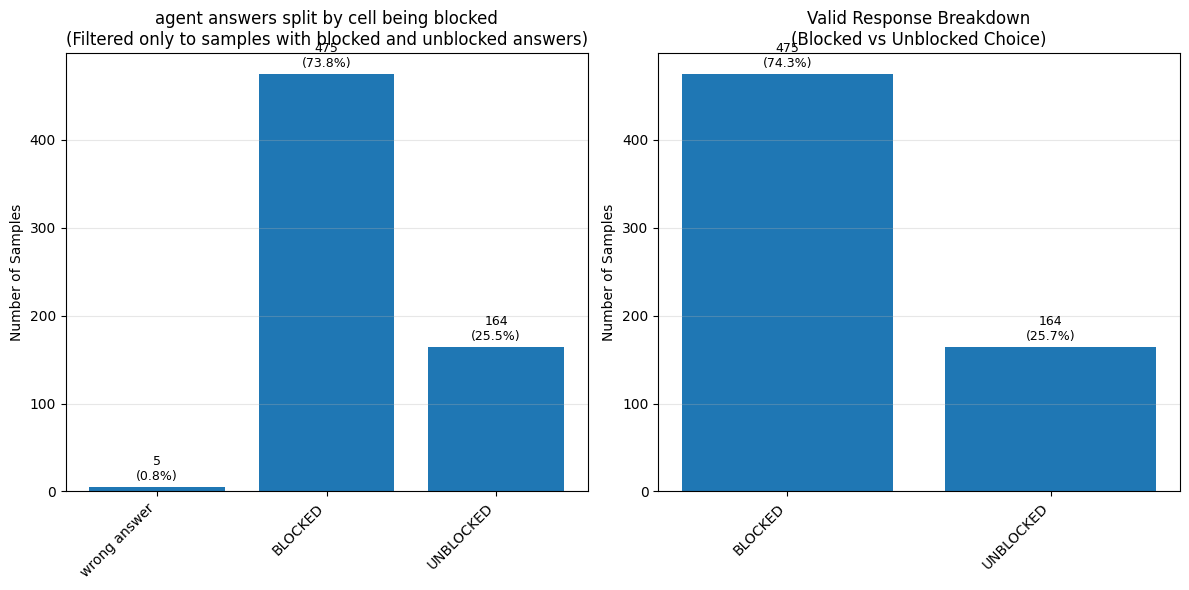

In [25]:
# Analysis of filtered samples: agent choice patterns for blocked vs unblocked cells
import json

def parse_agent_response(response_str):
    """Parse agent response to extract coordinate"""
    if not response_str:
        return None
    
    response = str(response_str).strip()
    
    # Try to parse as coordinate like "A1", "B2", "C3"
    if len(response) >= 2:
        try:
            col = ord(response[0].upper()) - ord('A')
            row = int(response[1:]) - 1
            return [col, row]
        except (ValueError, IndexError):
            pass
    
    return None

def coords_match(coord1, coord2):
    """Check if two coordinates match (handling different formats)"""
    if coord1 is None or coord2 is None:
        return False
    
    # Convert both to [col, row] format
    c1 = coord1 if isinstance(coord1, list) else [coord1[0], coord1[1]]
    c2 = coord2 if isinstance(coord2, list) else [coord2[0], coord2[1]]
    
    return c1[0] == c2[0] and c1[1] == c2[1]

# Analyze filtered samples
filtered_analysis = {
    'total_filtered': len(filtered_samples),
    'agent_wrong': 0,  # Response not in answer list
    'agent_picked_unblocked': 0,
    'agent_picked_blocked': 0,
    'unparseable_responses': 0
}

print(f"Analyzing {len(filtered_samples)} filtered samples...")

for sample in filtered_samples:
    # Get agent response
    agent_response = sample.output.completion if sample.output else None
    agent_coord = parse_agent_response(agent_response)
    
    # Get answer coordinates
    answer_coords = sample.metadata.get('answer_coordinates', [])
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    # Get items for blocked checking
    items = sample.metadata.get('items', [])
    
    if agent_coord is None:
        filtered_analysis['unparseable_responses'] += 1
        continue
    
    # Check if agent response is in the answer list
    agent_in_answers = any(coords_match(agent_coord, ans_coord) for ans_coord in answer_coords)
    
    if not agent_in_answers:
        filtered_analysis['agent_wrong'] += 1
    else:
        # Agent picked a valid answer - check if it's blocked or unblocked
        agent_blocked = check_if_blocked(agent_coord, items)
        
        if agent_blocked:
            filtered_analysis['agent_picked_blocked'] += 1
        else:
            filtered_analysis['agent_picked_unblocked'] += 1

# Calculate percentages
total = filtered_analysis['total_filtered']
print(f"\n=== FILTERED SAMPLES ANALYSIS ===")
print(f"Total filtered samples: {total}")
print(f"Unparseable responses: {filtered_analysis['unparseable_responses']} ({filtered_analysis['unparseable_responses']/total*100:.1f}%)")
print(f"Agent picked invalid answer: {filtered_analysis['agent_wrong']} ({filtered_analysis['agent_wrong']/total*100:.1f}%)")
print(f"Agent picked BLOCKED answer: {filtered_analysis['agent_picked_blocked']} ({filtered_analysis['agent_picked_blocked']/total*100:.1f}%)")
print(f"Agent picked UNBLOCKED answer: {filtered_analysis['agent_picked_unblocked']} ({filtered_analysis['agent_picked_unblocked']/total*100:.1f}%)")

# Additional analysis: of valid responses, what % were blocked vs unblocked?
valid_responses = filtered_analysis['agent_picked_blocked'] + filtered_analysis['agent_picked_unblocked']
if valid_responses > 0:
    print(f"\n=== OF VALID RESPONSES ONLY ===")
    print(f"Total valid responses: {valid_responses}")
    print(f"Chose BLOCKED: {filtered_analysis['agent_picked_blocked']} ({filtered_analysis['agent_picked_blocked']/valid_responses*100:.1f}%)")
    print(f"Chose UNBLOCKED: {filtered_analysis['agent_picked_unblocked']} ({filtered_analysis['agent_picked_unblocked']/valid_responses*100:.1f}%)")

# Create bar chart visualization
plt.figure(figsize=(12, 6))

# First subplot: Overall breakdown (excluding unparseable responses)
plt.subplot(1, 2, 1)
categories = ['wrong answer', 'BLOCKED', 'UNBLOCKED']
counts = [
    filtered_analysis['agent_wrong'],
    filtered_analysis['agent_picked_blocked'], 
    filtered_analysis['agent_picked_unblocked']
]

bars1 = plt.bar(categories, counts)
plt.title('agent answers split by cell being blocked\n(Filtered only to samples with blocked and unblocked answers)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars1, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/total*100:.1f}%)', 
             ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')

# Second subplot: Valid responses only
if valid_responses > 0:
    plt.subplot(1, 2, 2)
    valid_categories = ['BLOCKED', 'UNBLOCKED']
    valid_counts = [
        filtered_analysis['agent_picked_blocked'],
        filtered_analysis['agent_picked_unblocked']
    ]
    
    bars2 = plt.bar(valid_categories, valid_counts)
    plt.title('Valid Response Breakdown\n(Blocked vs Unblocked Choice)')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, count in zip(bars2, valid_counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count}\n({count/valid_responses*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=9)
    
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Filtering to samples where ALL correct answers are blocked...

=== ALL-BLOCKED SAMPLES FILTERING RESULTS ===
Total samples checked: 2000
Multiple choice samples: 2000
Samples where ALL correct answers are blocked: 356

=== ACCURACY COMPARISON ===
Mixed samples (blocked + unblocked answers): 639/644 = 0.992
All-blocked samples (all answers blocked): 318/356 = 0.893


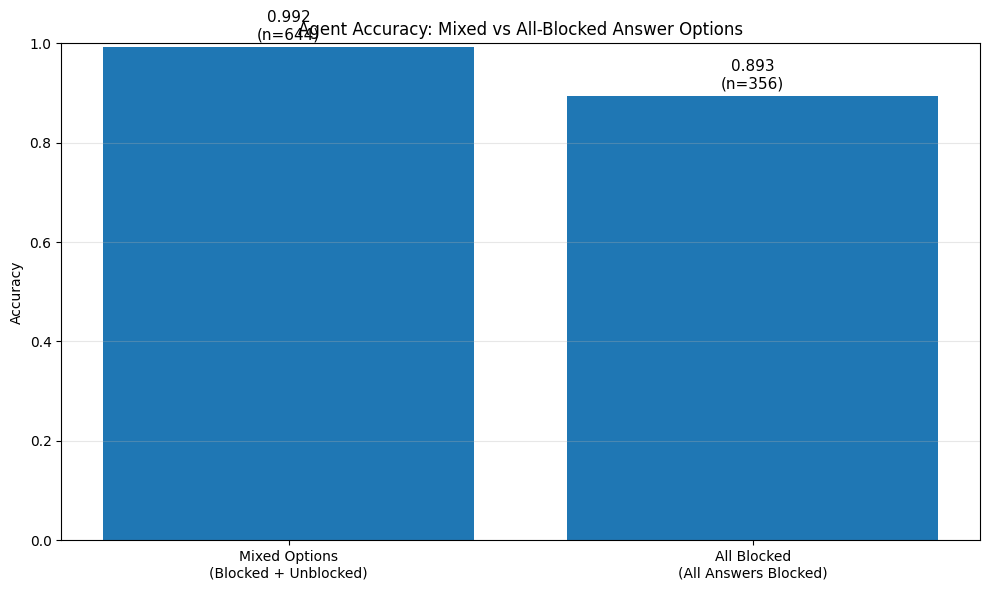


=== SUMMARY ===
Mixed samples (blocked + unblocked answers): 644 samples, 0.992 accuracy
All-blocked samples (all answers blocked): 356 samples, 0.893 accuracy
Accuracy difference: 0.099 (higher for mixed samples)


In [26]:
# Filter to samples where ALL correct answers are blocked
all_blocked_samples = []
all_blocked_stats = {
    'total_samples_checked': 0,
    'multiple_choice_samples': 0,
    'samples_with_all_blocked_answers': 0
}

print("Filtering to samples where ALL correct answers are blocked...")

for sample in log.samples:
    all_blocked_stats['total_samples_checked'] += 1
    
    # Get answer coordinates (the correct answers)
    answer_coords = sample.metadata.get('answer_coordinates', [])
    items = sample.metadata.get('items', [])
    
    if isinstance(answer_coords, str):
        try:
            answer_coords = json.loads(answer_coords)
        except:
            continue
    
    if not isinstance(answer_coords, list) or len(answer_coords) < 1:
        continue
    
    all_blocked_stats['multiple_choice_samples'] += 1
    
    # Check if ALL correct answers are blocked
    all_answers_blocked = True
    for coord in answer_coords:
        is_blocked = check_if_blocked(coord, items)
        if not is_blocked:
            all_answers_blocked = False
            break
    
    if all_answers_blocked:
        all_blocked_stats['samples_with_all_blocked_answers'] += 1
        all_blocked_samples.append(sample)

print(f"\n=== ALL-BLOCKED SAMPLES FILTERING RESULTS ===")
print(f"Total samples checked: {all_blocked_stats['total_samples_checked']}")
print(f"Multiple choice samples: {all_blocked_stats['multiple_choice_samples']}")
print(f"Samples where ALL correct answers are blocked: {all_blocked_stats['samples_with_all_blocked_answers']}")

# Calculate accuracy for different sample groups
def calculate_accuracy(sample_list, group_name):
    """Calculate accuracy for a list of samples"""
    if not sample_list:
        return 0, 0, 0
    
    correct_count = 0
    total_count = len(sample_list)
    
    for sample in sample_list:
        if sample.scores and len(sample.scores) > 0:
            is_correct = sample.score.value == "C"
            if is_correct:
                correct_count += 1
    
    accuracy = correct_count / total_count if total_count > 0 else 0
    print(f"{group_name}: {correct_count}/{total_count} = {accuracy:.3f}")
    return correct_count, total_count, accuracy

# Calculate accuracies for comparison
print(f"\n=== ACCURACY COMPARISON ===")
_, _, mixed_accuracy = calculate_accuracy(filtered_samples, "Mixed samples (blocked + unblocked answers)")
_, _, all_blocked_accuracy = calculate_accuracy(all_blocked_samples, "All-blocked samples (all answers blocked)")

# Create comparison bar chart
plt.figure(figsize=(10, 6))

groups = ['Mixed Options\n(Blocked + Unblocked)', 'All Blocked\n(All Answers Blocked)']
accuracies = [mixed_accuracy, all_blocked_accuracy]
sample_counts = [len(filtered_samples), len(all_blocked_samples)]

# Create bars
bars = plt.bar(groups, accuracies)

# Add value labels on bars
for bar, accuracy, count in zip(bars, accuracies, sample_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.3f}\n(n={count})', 
             ha='center', va='bottom', fontsize=11)

plt.ylabel('Accuracy')
plt.title('Agent Accuracy: Mixed vs All-Blocked Answer Options')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Mixed samples (blocked + unblocked answers): {len(filtered_samples)} samples, {mixed_accuracy:.3f} accuracy")
print(f"All-blocked samples (all answers blocked): {len(all_blocked_samples)} samples, {all_blocked_accuracy:.3f} accuracy")
if len(all_blocked_samples) > 0 and len(filtered_samples) > 0:
    accuracy_diff = mixed_accuracy - all_blocked_accuracy
    print(f"Accuracy difference: {accuracy_diff:.3f} ({'higher' if accuracy_diff > 0 else 'lower'} for mixed samples)")